In [1]:
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Download package NLTK
nltk.download('punkt')
try:
    nltk.download('punkt_tab') # Ditambahkan try-except jaga-jaga kalau error di beberapa versi
except:
    pass

[nltk_data] Downloading package punkt to C:\Users\HP
[nltk_data]     840\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\HP
[nltk_data]     840\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
# Inisialisasi Sastrawi Stopword Remover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

In [3]:
manchaster_sentence = """
Manchester City makes history by winning Club World Cup

Manchester City capped off its incredible year with yet another trophy, dismantling Fluminense 4-0 to win the Club World Cup on Friday.

Having already won the Premier League, Champions League, FA Cup and Super Cup, Pep Guardiola’s side now boasts five trophies this calendar year, becoming the first English club to ever hold all those titles simultaneously.

The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.

“We’ve shown over the past 12 months we are the best team in the world. Our results prove that and the consistency we have managed has been amazing,” club captain Kyle Walker said after the game, per Sky Sports.

“To win these five trophies – for me, the five biggest prizes available to us – is incredible. I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players. I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.

Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Aké free to shoot from distance. The defender’s effort cannoned back off the post but forward Julián Álvarez was in the right place to turn the rebound into the net with his chest.

City continued to look dangerous and doubled its lead before the break after Phil Foden’s attempted cross was deflected into his own net by Fluminense defender Nino.

Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.

The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.

City’s defence was largely untested for during the game, underlining the team’s dominance during this unforgettable year.

“As a manager it is what I am most proud of; that we are always there. No matter how much we win, no matter what trophies we lift, we are there again to fight for the next one,” City boss Guardiola said after the match, according to Sky Sports.

“To win the Treble was truly special, but to win two more trophies and now hold these five major titles shows the unique mentality of this team, of the Club and its fans.

“It is something no other English team has ever achieved, and we will always remember this incredible time we spent together.”

The game ended in some unsavoury scenes as a scuffle broke out between players on the pitch after the final whistle, but the game will be remembered as yet another successful night for City.

The champion heads back to England where it faces a tough title defence in the Premier League.

It currently sits fourth in the table and will face Everton in its next fixture on Wednesday.
"""

In [4]:
# 1. Tokenisasi Kalimat
sent_token1 = sent_tokenize(manchaster_sentence)

# 2. Stopword Removal (Membersihkan kata hubung)
cleaned_sentences1 = [stopword_remover.remove(sent) for sent in sent_token1]

# 3. Ekstraksi Fitur TF-IDF
vectorizer1 = TfidfVectorizer()
features1 = vectorizer1.fit_transform(cleaned_sentences1)
feature_names1 = vectorizer1.get_feature_names_out()

# 4. Fungsi Bantuan untuk melihat TF-IDF
def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
    sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
    tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
    tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
    return tfidf_df

Visualisasi TF-IDF Kalimat Pertama:


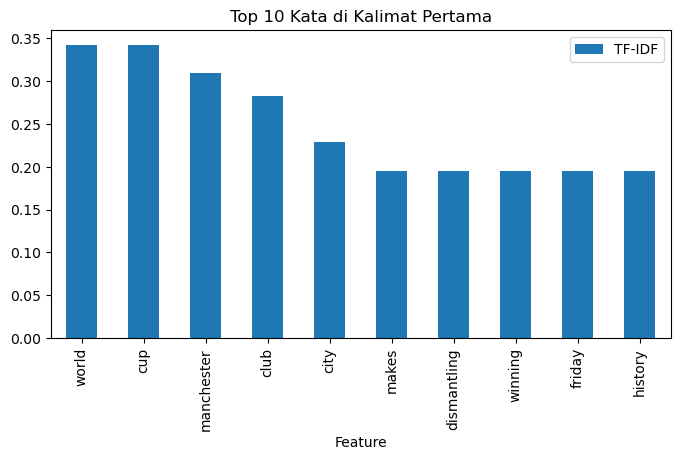

In [5]:
# Menampilkan Grafik Top 10 Kata di Kalimat Pertama
print("Visualisasi TF-IDF Kalimat Pertama:")
df_sent1 = get_tfidf_for_sentence(features1, 0, feature_names1)
df_sent1.head(10).plot(x='Feature', y='TF-IDF', kind='bar', title='Top 10 Kata di Kalimat Pertama', figsize=(8,4))
plt.show()

In [6]:
# 5. Menghitung Skor Kalimat
sent_index1 = 0
sent_scores1 = []

for i in features1:
    sent_score1 = i.sum()
    sent_length1 = len(i.data)

    # Rata-rata skor (hindari pembagian dengan 0)
    avg_score1 = sent_score1 / sent_length1 if sent_length1 > 0 else 0

    sent_scores1.append(avg_score1)
    sent_index1 += 1


Visualisasi Rata-Rata Skor Setiap Kalimat:


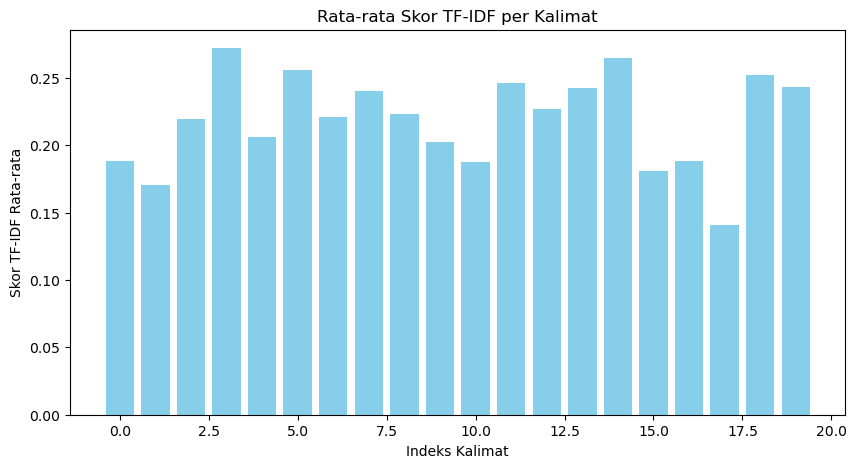

In [7]:
# Menampilkan Grafik Rata-Rata Skor Semua Kalimat
print("\nVisualisasi Rata-Rata Skor Setiap Kalimat:")
plt.figure(figsize=(10, 5))
plt.bar(range(len(sent_scores1)), sent_scores1, color='skyblue')
plt.title('Rata-rata Skor TF-IDF per Kalimat')
plt.xlabel('Indeks Kalimat')
plt.ylabel('Skor TF-IDF Rata-rata')
plt.show()

In [8]:
# 6. Final Summarization (Batas Threshold)
threshold1 = sum(sent_scores1) / len(sent_scores1)
print("\nThreshold (Average of Sentence Scores):", threshold1)

final_summ1 = ""


Threshold (Average of Sentence Scores): 0.21879218853733465


In [9]:
# Menampilkan list kalimat yang lolos seleksi
print("\n**Summary Sentences:**")
for index, data in enumerate(sent_scores1):
    if data >= threshold1:
        final_summ1 = final_summ1 + "\n" + sent_token1[index]
        print("- ", sent_token1[index])


**Summary Sentences:**
-  The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.
-  “We’ve shown over the past 12 months we are the best team in the world.
-  “To win these five trophies – for me, the five biggest prizes available to us – is incredible.
-  I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.
-  I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.
-  Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Aké free to shoot from distance.
-  Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.
-  The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.
-  City’s defence was largely untested for during the game, underlining the team’s domi

In [10]:
# Menampilkan hasil teks ringkasan utuh
print("\n**Final Summarization Result:**")
print(final_summ1.strip())


**Final Summarization Result:**
The final piece of the jigsaw came on a highly charged night in Saudi Arabia as Manchester City outclassed its Brazilian opponents.
“We’ve shown over the past 12 months we are the best team in the world.
“To win these five trophies – for me, the five biggest prizes available to us – is incredible.
I am so proud to have been a part of this and I can honestly say it’s an honour to play alongside these players.
I couldn’t ask for better teammates.”

It took just 40 seconds for Manchester City to take the lead.
Brazilian left-back Marcelo miscued a pass in the opening exchanges which let Nathan Aké free to shoot from distance.
Foden then got on the scoresheet himself in the 72nd minute after a prodding home from close range.
The rout was completed in the 88th minute when Álvarez capped off a brilliant performance with a clinical finish into the far corner.
City’s defence was largely untested for during the game, underlining the team’s dominance during this 